# 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_segmentation.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isna().sum().sum()

np.int64(24)

In [8]:
df.dropna(inplace = True)

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [11]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [14]:
df["Age"] = 2025 - df["Year_Birth"]

In [15]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [17]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
df["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [20]:
spend_cols = ["MntWines","MntFruits",
       "MntMeatProducts", "MntFishProducts", "MntSweetProducts"]

In [21]:
df["Total_Spending"] = df[spend_cols].sum(axis = 1)

In [22]:
df[("Total_Spending")]

0       1529
1         21
2        734
3         48
4        407
        ... 
2235    1094
2236     436
2237    1217
2238     782
2239     151
Name: Total_Spending, Length: 2216, dtype: int64

In [23]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [24]:
df["Customer_Since"]

0       5039
1       4489
2       4688
3       4515
4       4537
        ... 
2235    4757
2236    4395
2237    4531
2238    4532
2239    4998
Name: Customer_Since, Length: 2216, dtype: int64

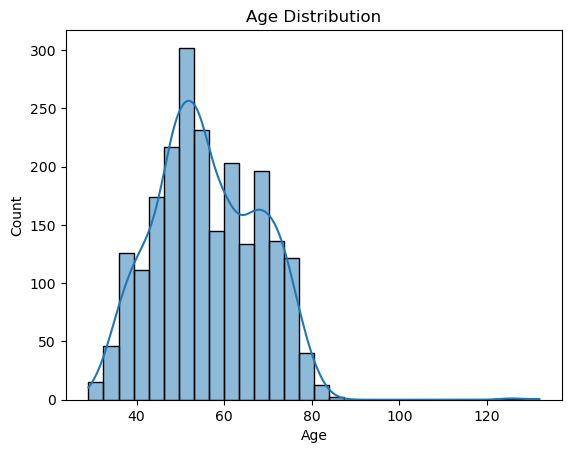

In [25]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

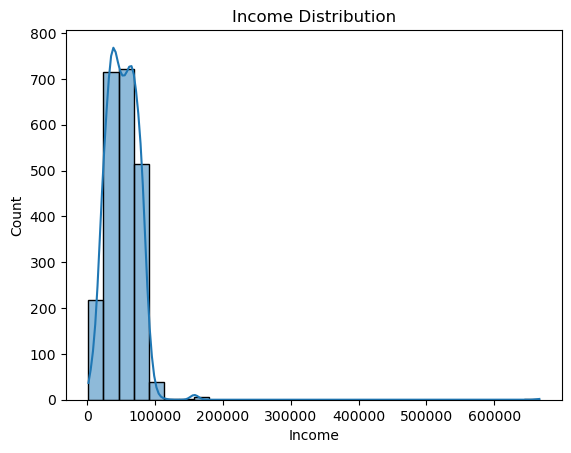

In [26]:
sns.histplot(df["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

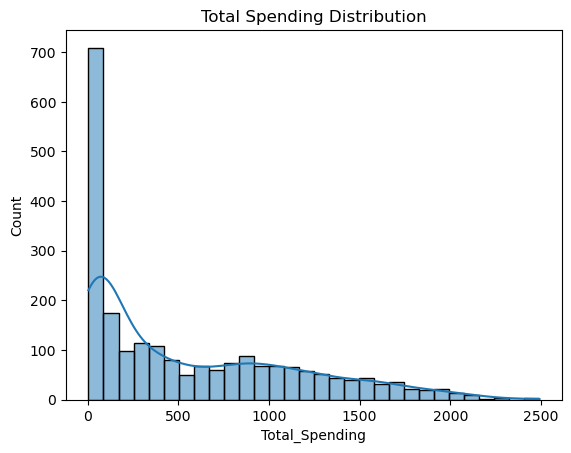

In [27]:
sns.histplot(df["Total_Spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

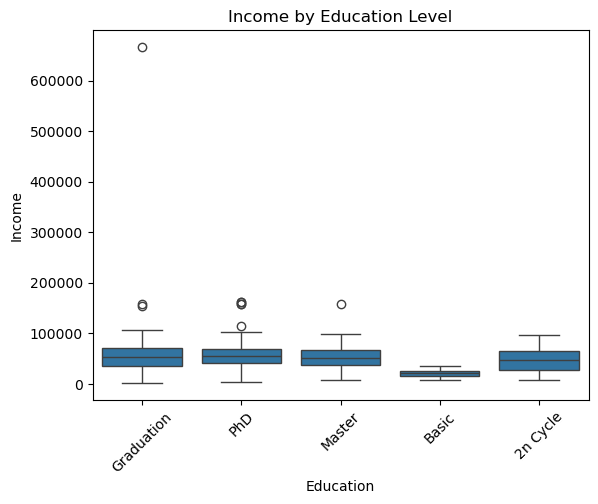

In [28]:
sns.boxplot(x="Education", y="Income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

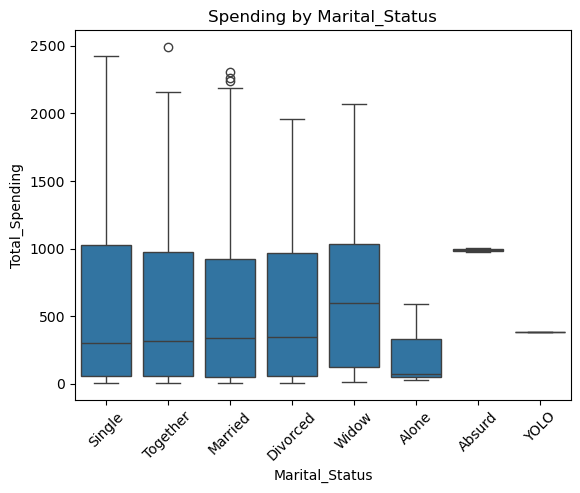

In [29]:
sns.boxplot(x="Marital_Status", y="Total_Spending", data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital_Status")
plt.show()

In [30]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [31]:
corr = df[["Income","Age","Recency","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()

In [32]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.668062,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.112779,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.019374,-0.005641,-0.000434
Total_Spending,0.668062,0.112779,0.019374,1.000000,0.515999,0.670327
NumWebPurchases,0.387878,0.153051,-0.005641,0.515999,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.670327,0.516240,1.000000


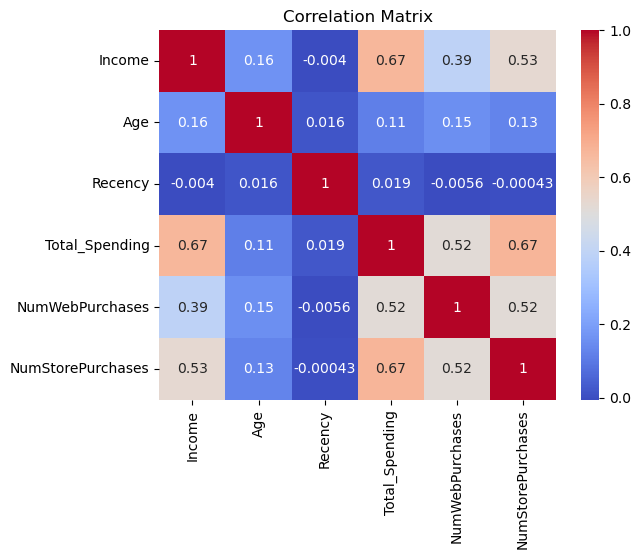

In [33]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
pivot_income = df.pivot_table(
    values="Income",
    index="Education",
    columns="Marital_Status",
    aggfunc="mean"
)

In [35]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


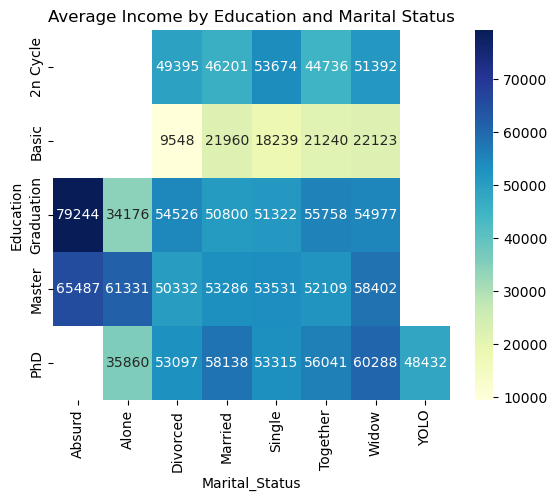

In [37]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Income by Education and Marital Status")
plt.show()

In [38]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending = False)

In [39]:
group1

Education
PhD           644.330561
Graduation    571.002688
Master        569.578082
2n Cycle      448.050000
Basic          58.962963
Name: Total_Spending, dtype: float64

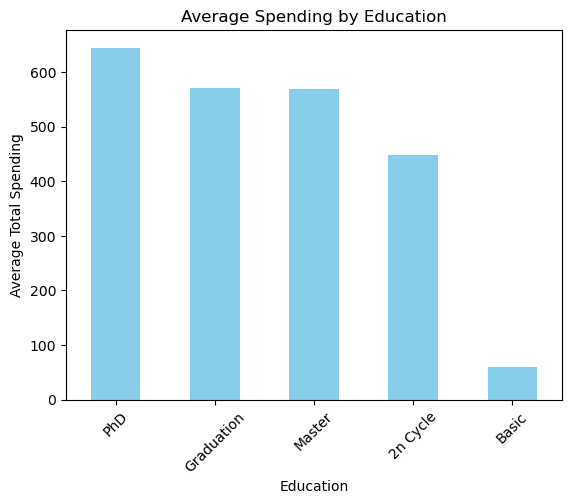

In [41]:
group1.plot(kind="bar",color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [45]:
df["AcceptedAny"] = df[
    ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
     "AcceptedCmp4", "AcceptedCmp5", "Response"]
].sum(axis=1)

In [47]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [49]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [50]:
df["AcceptedAny"].unique()

array([1, 0])

In [52]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending = False)

In [53]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

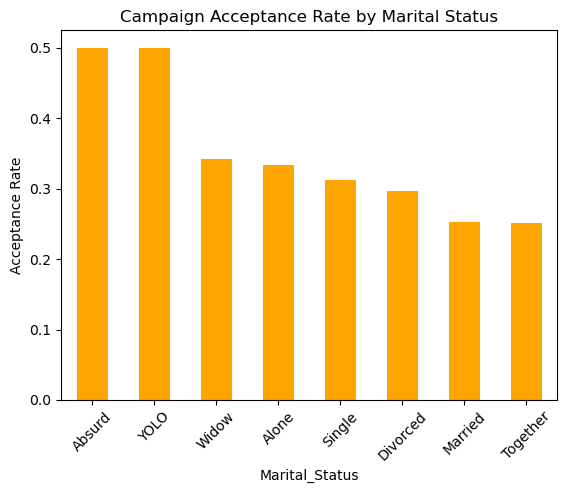

In [56]:
group2.plot(kind = "bar", color = "orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation = 45)
plt.show()

In [57]:
bins = [18,30,40,50,60,70,90]

In [60]:
labels = ["18-29","30-39","40-49","50-59","60-69","70+"]

In [61]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [62]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [64]:
group3 = df.groupby("AgeGroup", observed=False)["Income"].mean()

In [65]:
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

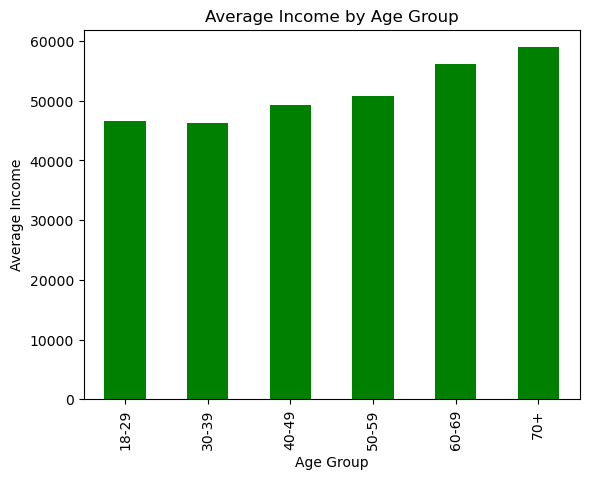

In [67]:
group3.plot(kind="bar", color="green")
plt.title("Average Income by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Income")
plt.show()

In [68]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1529,5039,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,21,4489,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,734,4688,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,48,4515,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,407,4537,0,40-49


In [70]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [77]:
features = ["Age","Income" , "Total_Spending" , "NumWebPurchases" , "NumStorePurchases",  "NumWebVisitsMonth",  "Recency"]

In [79]:
X = df[features].copy()

In [80]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1529,8,4,7,58
1,71,46344.0,21,1,2,5,38
2,60,71613.0,734,8,10,4,26
3,41,26646.0,48,2,4,6,26
4,44,58293.0,407,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1094,9,4,5,46
2236,79,64014.0,436,8,5,7,56
2237,44,56981.0,1217,2,13,6,91
2238,69,69245.0,782,6,10,3,8


In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [82]:
X_scaled = scaler.fit_transform(X)

In [83]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67383183, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.93944575, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.29614239, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.13315371, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.37932364, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7141632 , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [84]:
from sklearn.cluster import KMeans


In [85]:
wcss = []

In [86]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [87]:
wcss

[10239.690241358343,
 9030.208530856939,
 8259.260983328955,
 7590.150138680371,
 7113.48960122352,
 6799.865491772907,
 6468.7925685181635,
 6292.17609986226]

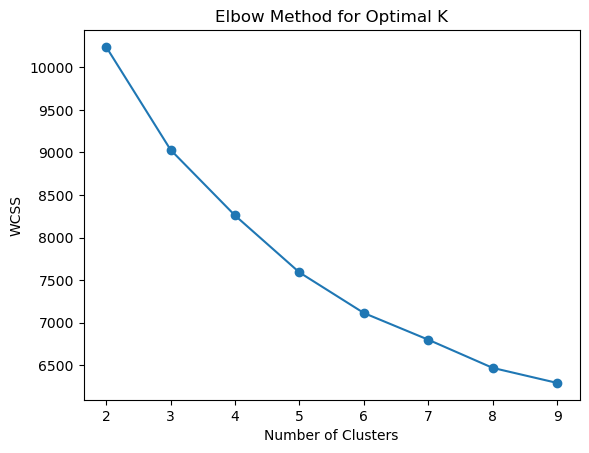

In [89]:
plt.plot(range(2,10),wcss,marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [91]:
kmeans = KMeans(n_clusters = 6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [93]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1529,5039,1,60-69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,21,4489,0,70+,4
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,734,4688,0,50-59,5
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,1,48,4515,0,40-49,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,1,407,4537,0,40-49,0


In [94]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [95]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,60.086957,61101.270903,858.421405,7.454849,7.976589,5.879599,73.698997
1,48.820000,32271.282222,86.797778,2.128889,3.142222,6.675556,25.055556
2,55.457883,79416.036717,1294.304536,4.246220,8.358531,2.218143,51.704104
3,49.349593,32735.476965,95.552846,2.330623,3.184282,7.059621,76.685637
4,69.153846,45126.576923,168.057692,2.516026,4.096154,5.105769,52.208333
5,59.120743,62105.399381,820.956656,6.981424,8.461300,5.572755,20.978328


In [96]:
df["Cluster"].value_counts()

Cluster
2    463
1    450
3    369
5    323
4    312
0    299
Name: count, dtype: int64

In [99]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

In [100]:
pca_data

array([[ 1.10135609, -0.2069141 ],
       [-1.32167074,  0.25367219],
       [ 1.88954561, -1.01981532],
       ...,
       [ 1.19483713,  1.16409974],
       [ 1.88280934, -1.17528269],
       [-0.83687269, -0.17102343]], shape=(2216, 2))

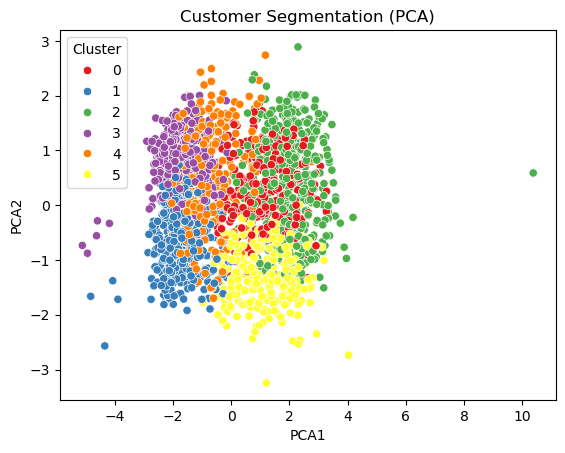

In [103]:
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df,
    palette="Set1"
)

plt.title("Customer Segmentation (PCA)")
plt.show()

In [104]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,60.086957,61101.270903,858.421405,7.454849,7.976589,5.879599,73.698997
1,48.820000,32271.282222,86.797778,2.128889,3.142222,6.675556,25.055556
2,55.457883,79416.036717,1294.304536,4.246220,8.358531,2.218143,51.704104
3,49.349593,32735.476965,95.552846,2.330623,3.184282,7.059621,76.685637
4,69.153846,45126.576923,168.057692,2.516026,4.096154,5.105769,52.208333
5,59.120743,62105.399381,820.956656,6.981424,8.461300,5.572755,20.978328


In [105]:
import joblib

joblib.dump(kmeans,"kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']